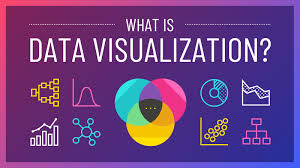

## 🥸 Exploratory data analysis

### 🎒 Packages

In [23]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_colwidth', None)
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
import random

### 🚙 Utilities

#### nltk packages downloading

In [13]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/zun/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
train_path = Path("..") / "data" / "train" / "train.tsv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / "data" / "test" / "train.tsv"

#### random colors for plot

In [26]:
pastel_colors = sns.color_palette("pastel")

In [28]:
def color():
    color = random.choice(pastel_colors)
    return color

### 📊 Data

#### 🥐 Read the tsv file

Mapping between numbers in `Sentiment` and actually sentiment
- 0 - 😡 negative
- 1 - 😤 somewhat negative
- 2 - 😐 neutral
- 3 - 😀 somewhat positive
- 4 - 😁 positive

In [3]:
df = pd.read_csv(
    train_path,
    sep="\t"
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156060 entries, 0 to 156059
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   PhraseId    156060 non-null  int64
 1   SentenceId  156060 non-null  int64
 2   Phrase      156060 non-null  str  
 3   Sentiment   156060 non-null  int64
dtypes: int64(3), str(1)
memory usage: 4.8 MB


In [4]:
eda_df = df.copy()

In [5]:
sentiment_mappings = {
    0 : "negative",
    1 : "somewhat negative",
    2 : "neural",
    3 : "somewhat positive",
    4 : "positive"
}

icon_mappings = {
    0 : "😡",
    1 : "😤",
    2 : "😐",
    3 : "😐",
    4 : "😁"
}

eda_df["SentimentName"] = eda_df["Sentiment"].map(sentiment_mappings)
eda_df["Icon"] = eda_df["Sentiment"].map(icon_mappings)

eda_df.head()

,PhraseId,SentenceId,Phrase,Sentiment,SentimentName,Icon
0,1,1,"A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .",1,somewhat negative,😤
1,2,1,A series of escapades demonstrating the adage that what is good for the goose,2,neural,😐
2,3,1,A series,2,neural,😐
3,4,1,A,2,neural,😐
4,5,1,series,2,neural,😐


### 

### 😚 Exploratory data analysis

#### 🤼‍♂️ Merge sentence phrases into a full sentence

In [6]:
phrases = eda_df[["SentenceId", "Phrase"]]

idx = phrases['Phrase'].str.len().groupby(phrases['SentenceId']).idxmax()
sentences_df = phrases.loc[idx].reset_index(drop=True)

sentences_df

,SentenceId,Phrase
0,1,"A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story ."
1,2,"This quiet , introspective and entertaining independent is worth seeking ."
2,3,"Even fans of Ismail Merchant 's work , I suspect , would have a hard time sitting through this one ."
3,4,"A positively thrilling combination of ethnography and all the intrigue , betrayal , deceit and murder of a Shakespearean tragedy or a juicy soap opera ."
4,5,Aggressive self-glorification and a manipulative whitewash .
...,...,...
8524,8540,... either you 're willing to go with this claustrophobic concept or you 're not .
8525,8541,"Despite these annoyances , the capable Clayburgh and Tambor really do a great job of anchoring the characters in the emotional realities of middle age ."
8526,8542,-LRB- Tries -RRB- to parody a genre that 's already a joke in the United States .
8527,8543,The movie 's downfall is to substitute plot for personality .


##### 💯 Result:
- There are 8529 independent sentences, the other sentences are generated using the technique "Each Sentence has been parsed into many phrases by the Stanford parser"

#### 😞 What is the class distribution of the dataset?

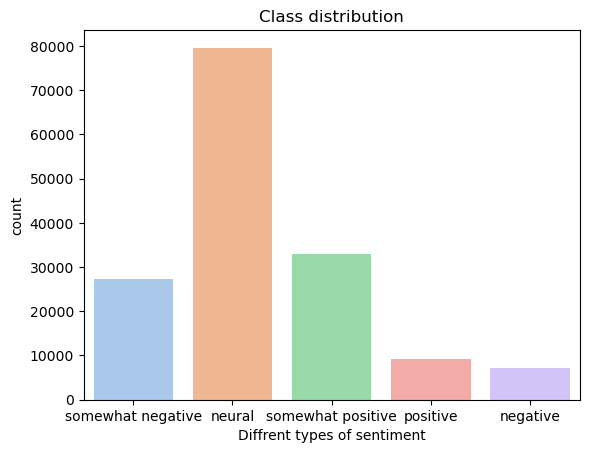

In [7]:
sns.countplot(data=eda_df, x="SentimentName", palette="pastel", hue="SentimentName")

plt.title("Class distribution")
plt.xlabel("Diffrent types of sentiment")
plt.show()

##### 💯 Result
---
- The dataset is imbalanced
- The number of neural samples dominates the other, the number of positive and negative sample are too small
##### 🌳 Possible decisions:
---
- Find a way to fix this imbalance?
- Oversampling/Undersampling

#### 🤧 What is the number of word/token per phrase?

In [19]:
word_count_df = eda_df.copy()

In [20]:
def get_word_count(row):
    tokens = word_tokenize(text=row["Phrase"])
    return len(tokens)

def get_character_count(row):
    return len(row["Phrase"])

In [21]:
word_count_df["Word count"] = word_count_df.apply(get_word_count, axis=1)
word_count_df["Character count"] = word_count_df.apply(get_character_count, axis=1)

In [22]:
word_count_df.head()

,PhraseId,SentenceId,Phrase,Sentiment,SentimentName,Icon,Word count,Character count
0,1,1,"A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .",1,somewhat negative,😤,37,188
1,2,1,A series of escapades demonstrating the adage that what is good for the goose,2,neural,😐,14,77
2,3,1,A series,2,neural,😐,2,8
3,4,1,A,2,neural,😐,1,1
4,5,1,series,2,neural,😐,1,6


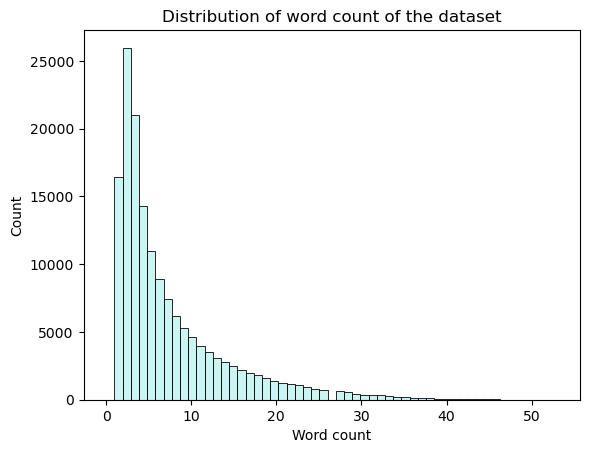

In [48]:
sns.histplot(data=word_count_df, x="Word count", color=color(), bins=55)

plt.title("Distribution of word count of the dataset")
plt.show()

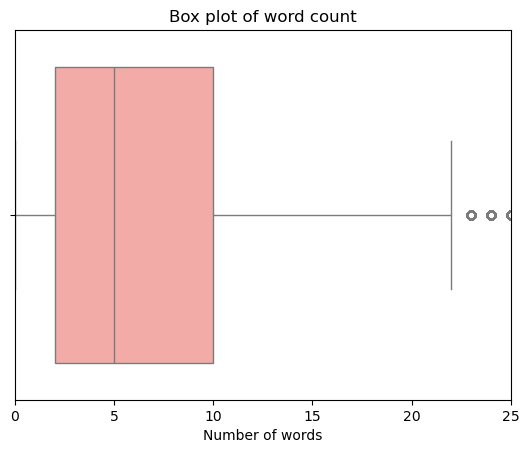

In [56]:
sns.boxplot(data=word_count_df, x="Word count", color=color())

plt.xlim((0, 25))
plt.xlabel("Number of words")
plt.title("Box plot of word count")
plt.show()

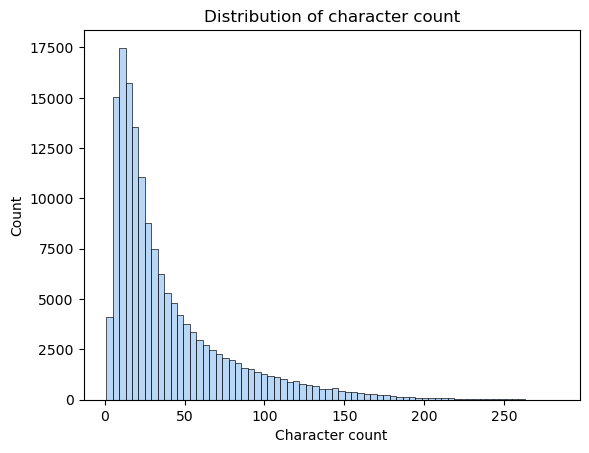

In [50]:
sns.histplot(data=word_count_df, x="Character count", color=color(), bins=70)

plt.title("Distribution of character count")
plt.show()

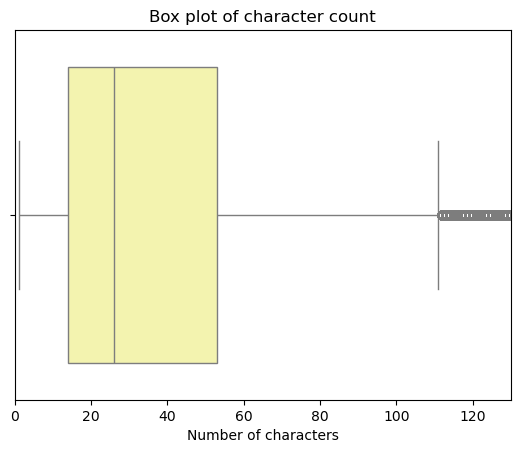

In [54]:
sns.boxplot(data=word_count_df, x="Character count", color=color())

plt.xlim((0, 130))
plt.xlabel("Number of characters")
plt.title("Box plot of character count")
plt.show()

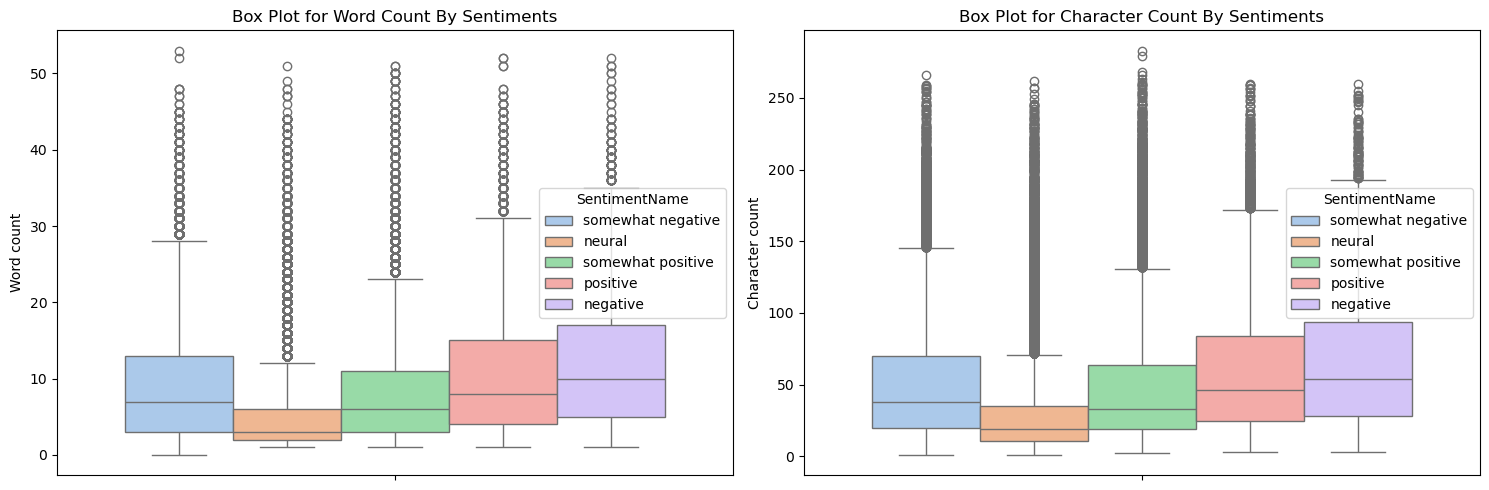

In [ ]:
# Figure
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Pass result of seaborn to ax
sns.boxplot(
    data=word_count_df,
    y="Word count",
    hue="SentimentName",
    palette="pastel",
    ax=axs[0]
)
axs[0].set_title("Box Plot")

# Pass result of seaborn to ax
sns.boxplot(
    data=word_count_df,
    y="Character count",
    hue="SentimentName",
    palette="pastel",
    ax=axs[1]
)

# Configure each ax
axs[0].set_title("Box Plot for Word Count By Sentiments")
axs[1].set_title("Box Plot for Character Count By Sentiments")

plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(7, 5))

# First plot
sns.boxplot(
    data=word_count_df,
    y="Word count",
    hue="SentimentName",
    palette="pastel",
    ax=axs
)
axs.set_title("Box Plot")

plt.tight_layout()
plt.show()

##### 💯 Result
- There are no substantial differences between the distribution of word count or character count between different sentiment classes (Though word count and character count in the case of negative phrases are a little bit higher compared with other classes)
---
##### 🌳 Possible decisions:
- some
---

#### 🛕 Templates

##### 💯 Result
- some
---
##### 🌳 Possible decisions:
- some
---